In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import gradio as gr
import warnings

# Mengabaikan warning agar output lebih bersih
warnings.filterwarnings('ignore')

In [2]:
# --- FUNGSI LOAD DATA ---
def load_and_clean_data(file_path):
    try:
        # Coba separator titik koma (;)
        df = pd.read_csv(file_path, sep=';', encoding='latin-1')
    except:
        # Fallback separator koma (,)
        df = pd.read_csv(file_path, sep=',', encoding='latin-1')

    # Bersihkan nama kolom
    df.columns = [c.strip() for c in df.columns]

    # Isi Medali kosong
    df['Medali'] = df['Medali'].fillna('Non-Medalis')
    
    # Feature Engineering: Identifikasi Juara
    medali_valid = ['Emas', 'Perak', 'Perunggu', 'Gold', 'Silver', 'Bronze']
    df['Is_Juara'] = df['Medali'].apply(lambda x: 1 if any(m in str(x) for m in medali_valid) else 0)

    # Feature Engineering: Skor Kualitas
    def hitung_bobot(medali):
        m = str(medali).lower()
        if 'emas' in m: return 4
        elif 'perak' in m: return 3
        elif 'perunggu' in m: return 2
        else: return 1
    
    df['Skor_Kualitas'] = df['Medali'].apply(hitung_bobot)
    
    # Pastikan tahun integer
    df = df.dropna(subset=['Tahun'])
    df['Tahun'] = df['Tahun'].astype(int)
    
    return df

# --- EKSEKUSI ---
filename = 'DATASET OSN.csv' # Pastikan nama file sesuai
try:
    df_raw = load_and_clean_data(filename)
    print(f"✅ Data Terload: {df_raw.shape[0]} baris.")
    print(df_raw.head(3))
except:
    print("❌ File tidak ditemukan. Upload 'DATASET OSN.csv' dulu.")
    df_raw = pd.DataFrame()

✅ Data Terload: 1000 baris.
   ï»¿Unnamed: 0                        Nama Peserta Gender  \
0          19572          Nyno Marcelo Devendy Turuk      L   
1          19573         Petrus Kalvin Andika Tamans      L   
2          19574  Prastya Marga Trisnaning Panggaluh      P   

                       Sekolah             Provinsi              Kab/Kota  \
0  SMP Seminari Pius XII Kisol  Nusa Tenggara Timur  Kab. Manggarai Timur   
1             SMPN 2 Mbetiling  Nusa Tenggara Timur  Kab. Manggarai Barat   
2             SMPN 1 Manokwari          Papua Barat        Kab. Manokwari   

       Bidang Jenjang Lomba Jenjang Sekolah  Kelas   Medali Prize Tambahan  \
0  Matematika           SMP             SMP    NaN  Finalis            NaN   
1  Matematika           SMP             SMP    NaN  Finalis            NaN   
2  Matematika           SMP             SMP    NaN  Finalis            NaN   

   Tahun  Is_Juara  Skor_Kualitas  
0   2019         0              1  
1   2019         0       

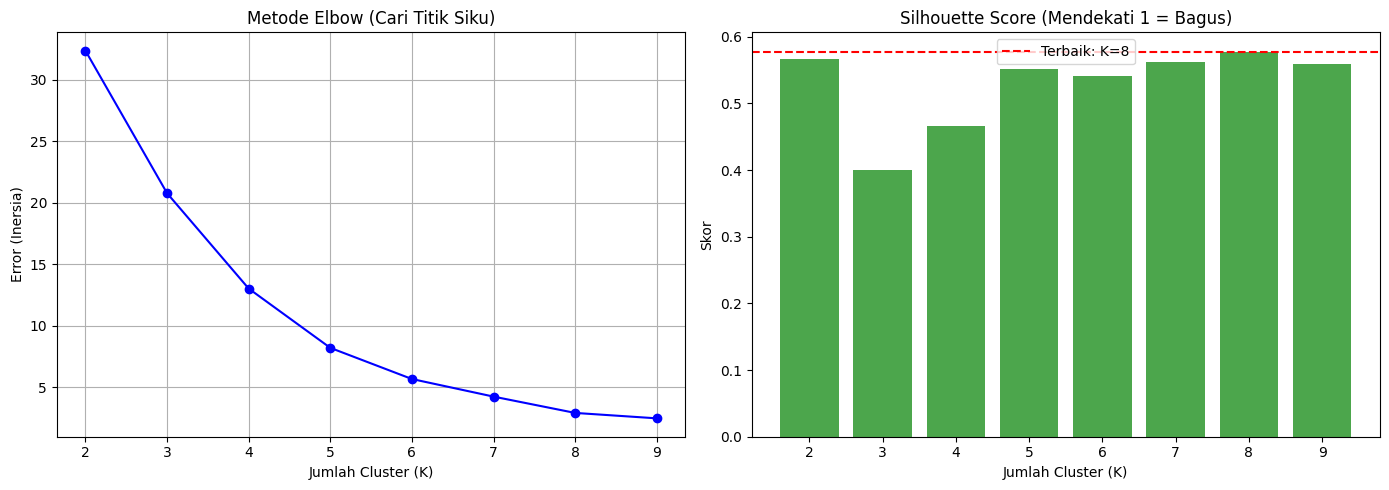

✅ Rekomendasi: Gunakan 8 Cluster pada Slider Gradio nanti.


In [3]:
# --- ANALISIS EVALUASI CLUSTER ---
def evaluasi_cluster(df, tahun="Semua Tahun"):
    if df.empty: return

    # 1. Filter Data
    if tahun != "Semua Tahun":
        df_filter = df[df['Tahun'] == int(tahun)]
    else:
        df_filter = df.copy()

    # 2. Agregasi Data (Siswa -> Provinsi)
    df_agg = df_filter.groupby('Provinsi').agg({
        'Nama Peserta': 'count',
        'Is_Juara': 'sum'
    }).reset_index()

    # PENTING: Rename kolom agar tidak KeyError
    df_agg.rename(columns={'Nama Peserta': 'Total_Peserta', 'Is_Juara': 'Total_Medali'}, inplace=True)
    
    # Hitung Win Rate
    df_agg['Win_Rate'] = (df_agg['Total_Medali'] / df_agg['Total_Peserta']) * 100
    df_agg = df_agg[df_agg['Total_Peserta'] > 0]

    if len(df_agg) < 5:
        print("⚠️ Data terlalu sedikit untuk evaluasi grafik.")
        return

    # 3. Scaling
    X = df_agg[['Total_Peserta', 'Win_Rate']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. Loop K-Means (Mencari K Terbaik)
    inertias = []
    sil_scores = []
    k_range = range(2, min(10, len(df_agg)))

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_scaled, km.labels_))

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafik Elbow
    ax1.plot(k_range, inertias, 'bo-')
    ax1.set_title("Metode Elbow (Cari Titik Siku)")
    ax1.set_xlabel("Jumlah Cluster (K)")
    ax1.set_ylabel("Error (Inersia)")
    ax1.grid(True)

    # Grafik Silhouette
    ax2.bar(k_range, sil_scores, color='green', alpha=0.7)
    ax2.set_title("Silhouette Score (Mendekati 1 = Bagus)")
    ax2.set_xlabel("Jumlah Cluster (K)")
    ax2.set_ylabel("Skor")
    
    # Tanda Skor Tertinggi
    best_score = max(sil_scores)
    best_k = k_range[sil_scores.index(best_score)]
    ax2.axhline(best_score, color='red', linestyle='--', label=f'Terbaik: K={best_k}')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    print(f"✅ Rekomendasi: Gunakan {best_k} Cluster pada Slider Gradio nanti.")

# Jalankan Evaluasi
if not df_raw.empty:
    evaluasi_cluster(df_raw, "Semua Tahun")

In [4]:
def logic_analisis(n_clusters, tahun):
    # Cek Data
    if df_raw.empty: return None, None, "Data Kosong"

    # 1. Filter & Agregasi
    if tahun != "Semua Tahun":
        df = df_raw[df_raw['Tahun'] == int(tahun)]
    else:
        df = df_raw.copy()

    df_agg = df.groupby('Provinsi').agg({
        'Nama Peserta': 'count',
        'Is_Juara': 'sum'
    }).reset_index()

    # Rename Kolom (PENTING)
    df_agg.rename(columns={'Nama Peserta': 'Total_Peserta', 'Is_Juara': 'Total_Medali'}, inplace=True)
    df_agg['Win_Rate'] = (df_agg['Total_Medali'] / df_agg['Total_Peserta']) * 100
    df_agg = df_agg[df_agg['Total_Peserta'] > 0]

    # Validasi Jumlah Data
    if len(df_agg) <= n_clusters:
        return None, None, f"Error: Data ({len(df_agg)}) kurang dari jumlah cluster ({n_clusters})."

    # 2. Modeling
    X = df_agg[['Total_Peserta', 'Win_Rate']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    df_agg['Cluster'] = labels

    # 3. Hitung Akurasi (Silhouette)
    try:
        score = silhouette_score(X_scaled, labels)
        if score > 0.7: ket = "Sangat Baik"
        elif score > 0.5: ket = "Baik"
        elif score > 0.25: ket = "Cukup"
        else: ket = "Buruk"
        score_text = f"{score:.3f} ({ket})"
    except:
        score_text = "N/A"

    # 4. Labeling & Formatting
    # Urutkan label agar Tier 1 = Win Rate Terendah/Partisipan
    centers = scaler.inverse_transform(km.cluster_centers_)
    sorted_idx = np.argsort(centers[:, 1]) # Sort by Win Rate
    mapping = {old: new for new, old in enumerate(sorted_idx)}
    df_agg['Label'] = df_agg['Cluster'].map(mapping)

    nama_tier = ['Perlu Evaluasi', 'Potensial', 'High Performance', 'Elite', 'Dominan']
    df_agg['Kategori'] = df_agg['Label'].apply(lambda x: nama_tier[x] if x < len(nama_tier) else f"Tier {x}")

    # 5. Visualisasi
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=df_agg, x='Total_Peserta', y='Win_Rate', hue='Kategori', palette='viridis', s=150, edgecolor='black', ax=ax)
    
    # Label top 10
    top = df_agg.nlargest(10, 'Win_Rate')
    for _, r in top.iterrows():
        ax.text(r['Total_Peserta'], r['Win_Rate'], r['Provinsi'], fontsize=9, fontweight='bold')

    ax.set_title(f"Peta Sebaran ({tahun})")
    ax.set_xlabel("Jumlah Peserta")
    ax.set_ylabel("Win Rate (%)")
    ax.grid(True, alpha=0.3)

    # Tabel Output
    df_out = df_agg[['Provinsi', 'Kategori', 'Win_Rate', 'Total_Peserta', 'Total_Medali']].sort_values('Win_Rate', ascending=False)
    df_out['Win_Rate'] = df_out['Win_Rate'].round(2)

    return fig, df_out, score_text

In [9]:
# --- DEPLOYMENT GRADIO (FIXED NO THEME) ---

# Siapkan dropdown tahun
if not df_raw.empty:
    years = sorted(df_raw['Tahun'].unique().tolist())
    years_str = ["Semua Tahun"] + [str(y) for y in years]
else:
    years_str = ["Semua Tahun"]

# HAPUS argumen theme=... agar tidak error
with gr.Blocks() as demo:
    gr.Markdown("# Dashboard Identifikasi Provinsi Terbaik OSN")
    
    with gr.Row():
        with gr.Column(scale=1):
            inp_k = gr.Slider(2, 5, value=3, step=1, label="Jumlah Cluster")
            inp_thn = gr.Dropdown(years_str, value="Semua Tahun", label="Tahun")
            btn = gr.Button("🔍 Analisis", variant="primary")
            
            # Output Skor
            out_skor = gr.Textbox(label="Kualitas Cluster (Silhouette Score)")
            
        with gr.Column(scale=3):
            out_plot = gr.Plot(label="Grafik Sebaran")

    out_tbl = gr.Dataframe(label="Tabel Detail")

    btn.click(logic_analisis, [inp_k, inp_thn], [out_plot, out_tbl, out_skor])

print(" Menjalankan Dashboard...")
demo.launch(share=True)

 Menjalankan Dashboard...
* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://d81bd7a543cf9071b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
